In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8")

# Load predictions
lgbm_test = pd.read_csv("../data/processed/lgbm_test_preds.csv")
gru_test = pd.read_csv("../data/processed/gru_test_preds.csv")

# Merge
df = lgbm_test.copy()
df["gru_pred"] = gru_test["gru_pred"]

df.head()

,Date,City,y_true,lgbm_pred,gru_pred
0,2023-01-01,Chennai,24.74,24.324754,24.801829
1,2023-01-02,Chennai,24.67,24.628663,25.319784
2,2023-01-03,Chennai,24.68,24.497908,25.469960
3,2023-01-04,Chennai,24.60,24.627206,25.707241
4,2023-01-05,Chennai,24.69,24.435412,25.321042


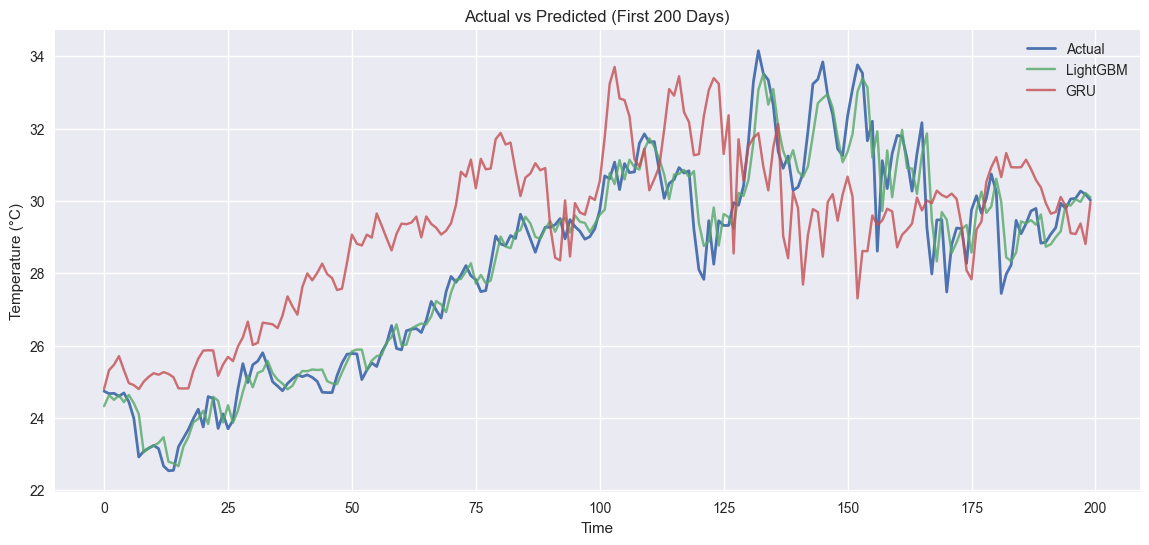

In [2]:
plt.figure(figsize=(14,6))

plt.plot(df["y_true"].values[:200], label="Actual", linewidth=2)
plt.plot(df["lgbm_pred"].values[:200], label="LightGBM", alpha=0.8)
plt.plot(df["gru_pred"].values[:200], label="GRU", alpha=0.8)

plt.legend()
plt.title("Actual vs Predicted (First 200 Days)")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.show()

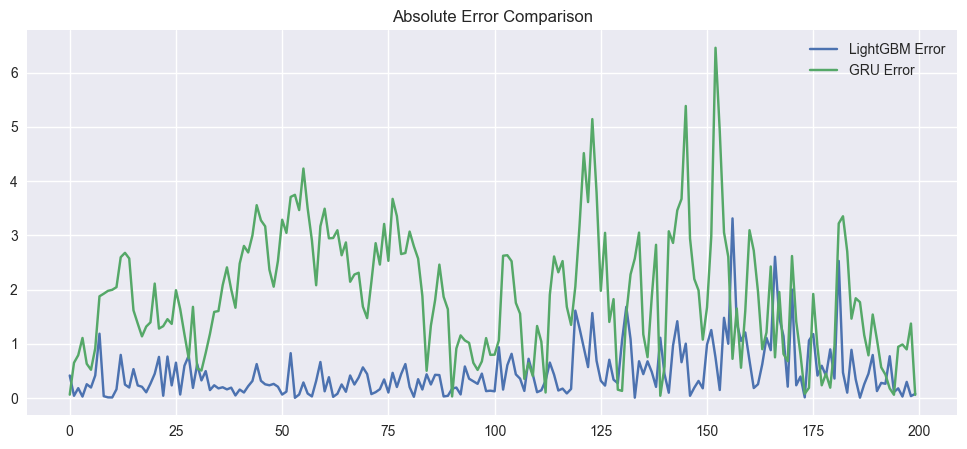

In [3]:
lgbm_error = np.abs(df["y_true"] - df["lgbm_pred"])
gru_error = np.abs(df["y_true"] - df["gru_pred"])

plt.figure(figsize=(12,5))

plt.plot(lgbm_error[:200], label="LightGBM Error")
plt.plot(gru_error[:200], label="GRU Error")

plt.legend()
plt.title("Absolute Error Comparison")
plt.show()

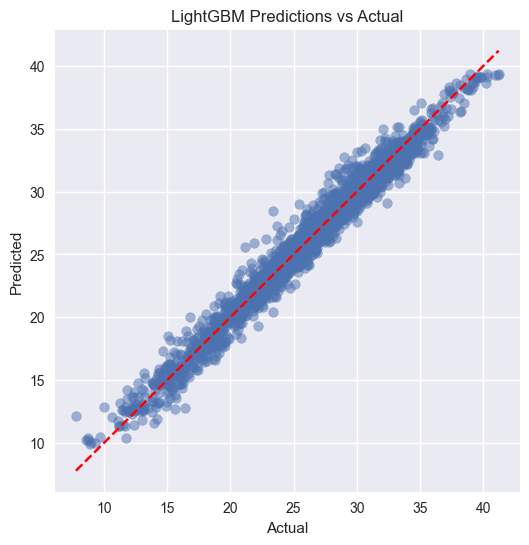

In [4]:
plt.figure(figsize=(6,6))

plt.scatter(df["y_true"], df["lgbm_pred"], alpha=0.5)
plt.plot([df["y_true"].min(), df["y_true"].max()],
         [df["y_true"].min(), df["y_true"].max()],
         'r--')

plt.title("LightGBM Predictions vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

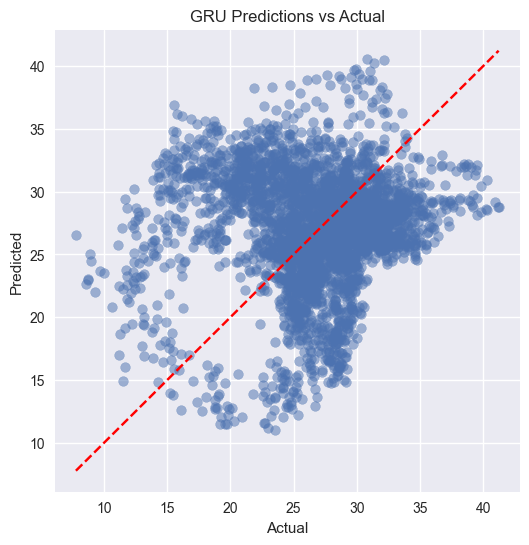

In [5]:
plt.figure(figsize=(6,6))

plt.scatter(df["y_true"], df["gru_pred"], alpha=0.5)
plt.plot([df["y_true"].min(), df["y_true"].max()],
         [df["y_true"].min(), df["y_true"].max()],
         'r--')

plt.title("GRU Predictions vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [8]:
df = pd.concat([
    lgbm_test.reset_index(drop=True),
    gru_test["gru_pred"].reset_index(drop=True)
], axis=1)

In [10]:
print("NaNs in y_true:", df["y_true"].isna().sum())
print("NaNs in lgbm:", df["lgbm_pred"].isna().sum())
print("NaNs in gru:", df["gru_pred"].isna().sum())

NaNs in y_true: 0
NaNs in lgbm: 0
NaNs in gru: 150


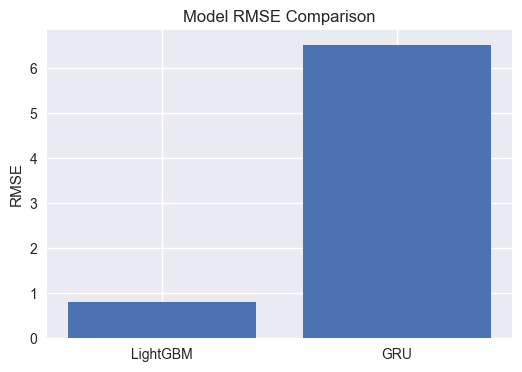

In [11]:
from sklearn.metrics import mean_squared_error

df_clean = df.dropna(subset=["y_true", "lgbm_pred", "gru_pred"])

lgbm_rmse = np.sqrt(mean_squared_error(df_clean["y_true"], df_clean["lgbm_pred"]))
gru_rmse = np.sqrt(mean_squared_error(df_clean["y_true"], df_clean["gru_pred"]))

models = ["LightGBM", "GRU"]
rmse_values = [lgbm_rmse, gru_rmse]

plt.figure(figsize=(6,4))
plt.bar(models, rmse_values)
plt.title("Model RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

In [7]:
print(len(lgbm_test), len(gru_test))

3650 3500


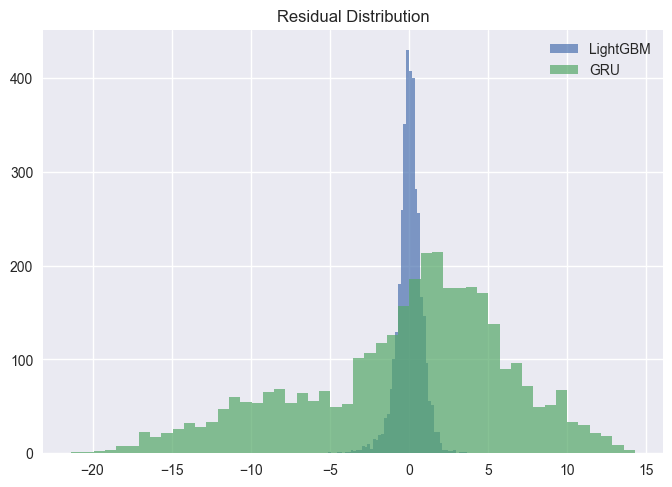

In [12]:
plt.hist(df["y_true"] - df["lgbm_pred"], bins=50, alpha=0.7, label="LightGBM")
plt.hist(df["y_true"] - df["gru_pred"], bins=50, alpha=0.7, label="GRU")

plt.legend()
plt.title("Residual Distribution")
plt.show()